# 04 — Bayesian model (pipeline)

**Model:** BYM2 regression on **standardised** `log1p` of LODES jobs at the **primary** travel-time threshold (`accessibility.travel_time_threshold_min`, default **45** min). Observation noise defaults to a **fixed** SD on the standardised scale (`model.obs_noise: fixed` in `configs/defaults.yaml`) so HMC does not fight a free `sigma_obs` vs spatial `sigma` ridge; set `obs_noise: estimated` to recover the old sampling `sigma_obs`. Optional **`model.likelihood: student_t`** for robust tails. Priors are calibrated for zero-mean unit-variance *y*; posteriors are **back-transformed** to log1p and job scales before export and maps. Random effects follow the [PyMC NYC BYM](https://www.pymc.io/projects/examples/en/latest/spatial/nyc_bym.html) parameterization: `σ · (√(1−ρ)·θ + √(ρ/s)·φ)` with `φ ~ ICAR(W)` and **Riebler scaling** `s` (not the unscaled `√ρ·φ` form).

**Reads:** latest `data/processed/accessibility/tract_accessibility_bundle__*.parquet`, latest `artifacts/tables/eda__acs_sd_tract_attributes__*.csv`, TIGER tracts (SD county), `configs/defaults.yaml` + `san_diego.yaml`.

**Writes:** `data/processed/posteriors/<run_id>_posterior_{samples,summary}.parquet`, `<run_id>_idata.nc`, `artifacts/tables/pipeline/pipeline__04_*__<run_id>.csv`, trace + maps under `artifacts/figures/`.

**Run id:** Use the cells below to set **`PIPELINE_RUN_ID`** to a **semantic** slug — **`fit_raw_zscore_x`** (raw z-scored **X**, paper primary) or **`fit_spatial_plus_x`** (**Spatial+** sensitivity) — instead of a calendar date. Match **notebook 05**. See `src.utils.config`. Rename legacy date-stamped BYM2 files by hand to match `LEGACY_BYM2_RUN_ID_TO_SEMANTIC` in `src.utils.config` if needed.

**Previous:** [`03_accessibility_computation.ipynb`](03_accessibility_computation.ipynb) · **Next:** [`05_posterior_analysis.ipynb`](05_posterior_analysis.ipynb)

### Run id (`RID`) — semantic BYM2 run (before setup)

| `PIPELINE_RUN_ID` | Meaning |
|-------------------|--------|
| **`fit_raw_zscore_x`** | BYM2 on **z-scored raw X** — apply cell sets `PIPELINE_NO_SPATIAL_PLUS=1`. **Paper primary** (D011). |
| **`fit_spatial_plus_x`** | BYM2 on **Spatial+ X** when that path exists in this notebook. **Sensitivity**. |

| Goal | Flags |
|------|--------|
| **Raw X (default)** | `SELECT_FIT_RAW_ZSCORE_X = True`, `SELECT_FIT_SPATIAL_PLUS_X = False` |
| **Spatial+** | `SELECT_FIT_SPATIAL_PLUS_X = True`, `SELECT_FIT_RAW_ZSCORE_X = False` |
| **Shell / CI** | Both `False` — export `PIPELINE_RUN_ID` yourself before Jupyter. |
| **Ad-hoc date stamp** | Both `False`, env unset → calendar date from `artifact_run_id()`. |

Run **apply**, then the **setup** cell. Do not set both selects `True` (restart kernel if needed).


**Note:** This repo snapshot of nb04 may implement only **raw z-scored X** in the model code. Use **it_spatial_plus_x** as PIPELINE_RUN_ID only when your notebook actually fits the Spatial+ estimand; otherwise you would mislabel outputs.


In [21]:
# Pin: **fit_raw_zscore_x** — raw z-scored covariates (paper primary)
SELECT_FIT_RAW_ZSCORE_X = True


In [22]:
# Pin: **fit_spatial_plus_x** — Spatial+ sensitivity (when implemented in this notebook)
SELECT_FIT_SPATIAL_PLUS_X = False


In [23]:
# Apply `PIPELINE_RUN_ID` (and raw-X env) before `artifact_run_id()` in the next cell
import os

_pin_raw = globals().get("SELECT_FIT_RAW_ZSCORE_X", False)
_pin_splus = globals().get("SELECT_FIT_SPATIAL_PLUS_X", False)
if _pin_raw and _pin_splus:
    raise RuntimeError("Only one of SELECT_FIT_RAW_ZSCORE_X / SELECT_FIT_SPATIAL_PLUS_X may be True.")
if _pin_raw:
    os.environ["PIPELINE_RUN_ID"] = "fit_raw_zscore_x"
    os.environ["PIPELINE_NO_SPATIAL_PLUS"] = "1"
elif _pin_splus:
    os.environ["PIPELINE_RUN_ID"] = "fit_spatial_plus_x"
    os.environ.pop("PIPELINE_NO_SPATIAL_PLUS", None)
print("PIPELINE_RUN_ID =", os.environ.get("PIPELINE_RUN_ID", "(unset -> calendar date in next cell)"))
print("PIPELINE_NO_SPATIAL_PLUS =", os.environ.get("PIPELINE_NO_SPATIAL_PLUS", "(unset)"))



PIPELINE_RUN_ID = fit_raw_zscore_x
PIPELINE_NO_SPATIAL_PLUS = 1


In [24]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

REPO_ROOT = next(
    (d for d in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (d / "configs" / "san_diego.yaml").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not find configs/san_diego.yaml.")
sys.path.insert(0, str(REPO_ROOT))

from src.utils.config import artifact_run_id, load_merged_config  # noqa: E402

CONFIG = load_merged_config(REPO_ROOT)
MODEL_CFG = CONFIG.get("model", {})
ACC_CFG = CONFIG.get("accessibility", {})
T_PRIMARY = int(ACC_CFG.get("travel_time_threshold_min", 45))
RID = artifact_run_id()
FAST = os.environ.get("PIPELINE_FAST_MCMC", "").strip() in ("1", "true", "yes")
if FAST:
    MODEL_CFG = {**MODEL_CFG, "draws": 80, "tune": 80, "chains": 2}

POSTERIOR_DIR = REPO_ROOT / "data" / "processed" / "posteriors"
POSTERIOR_DIR.mkdir(parents=True, exist_ok=True)
ART_TAB_EDA = REPO_ROOT / "artifacts" / "tables" / "eda"
ART_TAB_PIPE = REPO_ROOT / "artifacts" / "tables" / "pipeline"
ART_FIG = REPO_ROOT / "artifacts" / "figures"
ART_TAB_EDA.mkdir(parents=True, exist_ok=True)
ART_TAB_PIPE.mkdir(parents=True, exist_ok=True)
ART_FIG.mkdir(parents=True, exist_ok=True)

SEED = int(MODEL_CFG.get("random_seed", 42))
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

print(f"REPO_ROOT={REPO_ROOT}")
print(f"RUN_ID={RID}  T_PRIMARY={T_PRIMARY}min  FAST_MCMC={FAST}")
print(f"MCMC draws={MODEL_CFG.get('draws')} tune={MODEL_CFG.get('tune')} chains={MODEL_CFG.get('chains')}")
print(
    f"likelihood={MODEL_CFG.get('likelihood', 'normal')} obs_noise={MODEL_CFG.get('obs_noise', 'fixed')} "
    f"fixed_obs_sigma={MODEL_CFG.get('fixed_obs_sigma', 0.05)} target_accept={MODEL_CFG.get('target_accept')}",
)


REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
RUN_ID=fit_raw_zscore_x  T_PRIMARY=45min  FAST_MCMC=False
MCMC draws=8000 tune=4000 chains=4
likelihood=student_t obs_noise=fixed fixed_obs_sigma=0.05 target_accept=0.99


In [25]:
# Load accessibility bundle (latest by filename date), ACS attributes, TIGER tracts
import geopandas as gpd
from IPython.display import display

census_cfg = CONFIG.get("census", {})
state_fips = str(census_cfg.get("state_fips", CONFIG.get("state_fips", "06"))).zfill(2)
county_fips = str(census_cfg.get("county_fips", CONFIG.get("county_fips", "073"))).zfill(3)
acs_year = int(census_cfg.get("acs_year", 2023))

bundles = sorted((REPO_ROOT / "data" / "processed" / "accessibility").glob("tract_accessibility_bundle__*.parquet"))
if not bundles:
    raise FileNotFoundError("No tract_accessibility_bundle__*.parquet — run notebook 03 first.")
bundle_path = bundles[-1]

acs_files = sorted(ART_TAB_EDA.glob("eda__acs_sd_tract_attributes__*.csv"))
if not acs_files:
    raise FileNotFoundError("No eda__acs_sd_tract_attributes__*.csv — run EDA notebook 03 first.")
acs_path = acs_files[-1]

tiger_dir = REPO_ROOT / "data" / "raw" / "census" / f"tl_{acs_year}_{state_fips}_tract"
tiger_shp = tiger_dir / f"tl_{acs_year}_{state_fips}_tract.shp"
if not tiger_shp.is_file():
    raise FileNotFoundError(f"Missing TIGER shapefile: {tiger_shp}")

acc = pd.read_parquet(bundle_path)
acc["GEOID"] = acc["GEOID"].astype(str).str.zfill(11)

acs = pd.read_csv(acs_path)
acs["GEOID"] = acs["GEOID"].astype(str).str.zfill(11)

# Columns to load from ACS. disadvantage_z is the pre-computed composite used as
# the primary equity covariate in the model (replaces individual race/poverty vars
# which create spatial-confounding ridges with the ICAR field).
cov_raw = [
    "poverty_rate",       # loaded for reference / EDA but not passed to model
    "no_vehicle_hh_rate",
    "pct_hispanic",       # loaded for reference but not passed to model
    "pct_black",          # loaded for reference but not passed to model
    "B19013_001E",
    "B01003_001E",
    "disadvantage_z",     # composite: collapses race/poverty block → single covariate
]
usecols = ["GEOID"] + [c for c in cov_raw if c in acs.columns]
acs = acs[usecols]

tracts_all = gpd.read_file(tiger_shp)
tracts_all["GEOID"] = tracts_all["GEOID"].astype(str).str.zfill(11)
tracts_sd = tracts_all[tracts_all["COUNTYFP"] == county_fips].copy()

df = acc.merge(acs, on="GEOID", how="inner", suffixes=("", "_acs"))
df = df.merge(tracts_sd[["GEOID", "geometry"]], on="GEOID", how="inner")

job_cols = {30: "jobs_C000_30min", 45: "jobs_C000_45min", 60: "jobs_C000_60min"}
y_col = job_cols[T_PRIMARY]
if y_col not in df.columns:
    raise KeyError(f"Bundle missing column {y_col!r}")

# Drop tracts where the primary accessibility column is NaN.
# These are r5py routing failures (the origin had no reachable stops), not true
# zero-access tracts. Imputing 0 would place them ~6 SD below the mean on the
# standardised scale, creating extreme outliers that distort the likelihood.
nan_mask = pd.to_numeric(df[y_col], errors="coerce").isna()
if nan_mask.sum() > 0:
    print(f"Dropping {nan_mask.sum()} tracts with NaN {y_col} (r5py routing failures):")
    print(df.loc[nan_mask, "GEOID"].tolist())
    df = df[~nan_mask].reset_index(drop=True)

# Population density (people / km²) in projected CRS
tg = gpd.GeoDataFrame(df[["GEOID", "geometry"]], geometry="geometry", crs="EPSG:4326")
tg = tg.to_crs(3310)
area_km2 = tg.geometry.area / 1e6
pop = pd.to_numeric(df["B01003_001E"], errors="coerce").clip(lower=1.0)
df["pop_density_km2"] = pop / area_km2.replace(0, np.nan)

# Log median income (impute missing)
inc = pd.to_numeric(df["B19013_001E"], errors="coerce")
inc = inc.fillna(np.nanmedian(inc))
df["log_median_income"] = np.log(inc.clip(lower=1.0))

# Design matrix — 4 covariates (z-scored).
# disadvantage_z replaces individual race/poverty/no-vehicle block:
#   - removes pct_hispanic (worst spatial confounding: R-hat 1.071 in April 5 run)
#   - removes pct_black and poverty_rate (absorbed by spatial field; ESS < 200)
#   - collapses equity signal into a single pre-computed composite (β_sigma=0.3)
# no_vehicle_hh_rate retained: independent urban-form signal (β excludes 0 consistently).
# log_median_income + log_pop_density: primary structural geography drivers.
cov_model = [
    "disadvantage_z",
    "no_vehicle_hh_rate",
    "log_median_income",
    "log_pop_density",
]
df["log_pop_density"] = np.log1p(df["pop_density_km2"].fillna(0.0))

for c in cov_model:
    if c not in df.columns:
        raise KeyError(c)

X_raw = df[cov_model].apply(pd.to_numeric, errors="coerce").astype(float)
X_mean = X_raw.mean()
X_std = X_raw.std(ddof=1).replace(0, 1.0)
X_z = (X_raw - X_mean) / X_std
X_z.index = df["GEOID"].astype(str).str.zfill(11)

df["y_raw"] = pd.to_numeric(df[y_col], errors="coerce").fillna(0.0)
df["y_log"] = np.log1p(df["y_raw"])

# Quartile thresholds on observed job counts (city-specific "desert" cut)
q25 = {t: float(np.percentile(pd.to_numeric(df[job_cols[t]], errors="coerce").fillna(0.0), 25)) for t in (30, 45, 60)}

n_acc = len(acc)
n_merge = len(df)
display(
    pd.DataFrame(
        [
            {"stage": "accessibility rows", "n": n_acc},
            {"stage": "after dropping NaN-accessibility tracts", "n": n_merge},
        ]
    )
)

miss_acs = set(acc["GEOID"]) - set(acs["GEOID"])
miss_tg = set(acc["GEOID"]) - set(tracts_sd["GEOID"])
if miss_acs or miss_tg:
    print("GEOs in accessibility but not ACS:", len(miss_acs), "not in TIGER:", len(miss_tg))

if n_merge < 200:
    raise RuntimeError(f"Only {n_merge} tracts after filtering — check upstream data.")

print("Bundle:", bundle_path.relative_to(REPO_ROOT))
print("ACS:", acs_path.relative_to(REPO_ROOT))
print("Response:", y_col, "| q25 jobs (30/45/60 min):", q25)
print("Covariates:", cov_model)


Dropping 6 tracts with NaN jobs_C000_45min (r5py routing failures):
['06073009504', '06073018700', '06073019002', '06073020903', '06073021302', '06073990100']


,stage,n
0,accessibility rows,726
1,after dropping NaN-accessibility tracts,720


Bundle: data\processed\accessibility\tract_accessibility_bundle__2026-04-03.parquet
ACS: artifacts\tables\eda\eda__acs_sd_tract_attributes__2026-03-29.csv
Response: jobs_C000_45min | q25 jobs (30/45/60 min): {30: 1258.0, 45: 4470.0, 60: 11176.75}
Covariates: ['disadvantage_z', 'no_vehicle_hh_rate', 'log_median_income', 'log_pop_density']


In [26]:
# Queen adjacency + Riebler scaling factor (connected graph after island fix)
import matplotlib.pyplot as plt

from src.modeling.spatial import adjacency_from_queen, scaling_factor_sp

tracts_gdf = gpd.GeoDataFrame(df[["GEOID", "geometry"]], geometry="geometry", crs="EPSG:4326")
W, geoids_sp, diag_sp, tracts_ordered = adjacency_from_queen(tracts_gdf, id_col="GEOID", connect_islands=True)

scaling_factor = scaling_factor_sp(W)
print({k: v for k, v in diag_sp.items() if k != "geoid_order"})
print("Riebler scaling_factor:", round(scaling_factor, 6))

df_ix = df.set_index("GEOID").loc[geoids_sp].reset_index()
y_log = df_ix["y_log"].to_numpy(dtype=np.float64)
y_mean = float(np.mean(y_log))
y_sd = float(np.std(y_log, ddof=1))
if y_sd < 1e-12:
    y_sd = 1.0
y_std = (y_log - y_mean) / y_sd
X = X_z.loc[df_ix["GEOID"].astype(str).str.zfill(11)].to_numpy(dtype=np.float64)
cov_names = list(X_z.columns)

deg = W.sum(axis=1)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(deg, bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("Queen degree (# neighbors)")
ax.set_title("Tract contiguity degree distribution")
plt.tight_layout()
deg_path = ART_FIG / f"pipeline__04_degree_hist__{RID}.png"
fig.savefig(deg_path, dpi=150)
plt.close(fig)
print("Saved", deg_path.relative_to(REPO_ROOT))


C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\src\modeling\spatial.py:82: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = g.geometry.centroid


{'n_tracts': 720, 'n_edges': 2261, 'mean_degree': 6.280555555555556, 'min_degree': 1, 'max_degree': 16, 'n_islands': 0, 'is_symmetric': True}
Riebler scaling_factor: 1389.358577
Saved artifacts\figures\pipeline__04_degree_hist__fit_raw_zscore_x.png


Covariate order (z-scored in model): ['disadvantage_z', 'no_vehicle_hh_rate', 'log_median_income', 'log_pop_density']
beta_sigma prior: 0.3


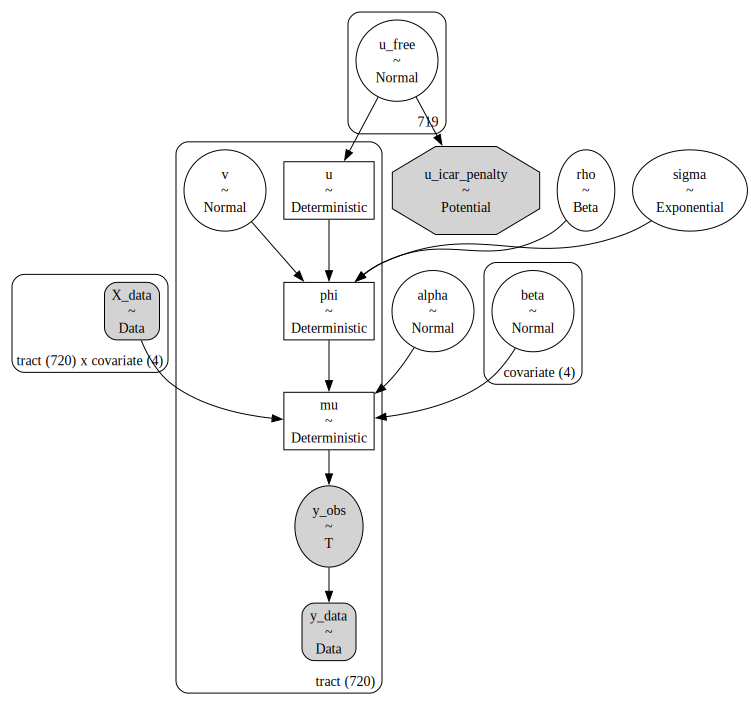

In [27]:
# PyMC BYM2 + Student-t likelihood on standardised log1p(y) (primary threshold)
from IPython.display import display

import importlib

import pymc as pm

import src.modeling.tract_bym as _tract_bym
importlib.reload(_tract_bym)
build_tract_bym_normal = _tract_bym.build_tract_bym_normal

model = build_tract_bym_normal(
    W=W,
    scaling_factor=scaling_factor,
    X=X,
    geoids=geoids_sp,
    cov_names=cov_names,
    y_std=y_std,
    likelihood=str(MODEL_CFG.get("likelihood", "normal")).lower(),
    obs_noise=str(MODEL_CFG.get("obs_noise", "fixed")).lower(),
    fixed_obs_sigma=float(MODEL_CFG.get("fixed_obs_sigma", 0.05)),
    estimated_obs_sigma_prior_scale=float(MODEL_CFG.get("estimated_obs_sigma_prior_scale", 0.2)),
    student_t_nu=float(MODEL_CFG.get("student_t_nu", 4.0)),
    beta_sigma=float(MODEL_CFG.get("beta_sigma", 0.5)),
)

print("Covariate order (z-scored in model):", cov_names)
print(f"beta_sigma prior: {MODEL_CFG.get('beta_sigma', 0.5)}")

try:
    gv = pm.model_to_graphviz(model)
    display(gv)
except Exception as e:
    print("model_to_graphviz skipped:", e)


In [28]:
# MCMC — save NetCDF immediately for crash safety
# init="advi+adapt_diag": runs a short ADVI pass before NUTS to pre-estimate the
# diagonal mass matrix. Reduces the number of warmup steps wasted on a bad geometry
# for correlated posteriors (spatial field × beta ridge). If ADVI diverges on your
# machine (rare with ICAR), change to init="jitter+adapt_diag_grad" as fallback.
idata_path = POSTERIOR_DIR / f"{RID}_idata.nc"

with model:
    idata = pm.sample(
        draws=int(MODEL_CFG["draws"]),
        tune=int(MODEL_CFG["tune"]),
        chains=int(MODEL_CFG["chains"]),
        target_accept=float(MODEL_CFG["target_accept"]),
        random_seed=SEED,
        init="advi+adapt_diag",
        return_inferencedata=True,
        progressbar=True,
    )

idata.to_netcdf(idata_path)
print("Saved", idata_path.relative_to(REPO_ROOT))


c:\Users\sardo\anaconda3\envs\bayestransit\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using advi+adapt_diag...


Output()

Convergence achieved at 106600
Interrupted at 106,599 [53%]: Average Loss = 2,771
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma, rho, v, u_free]


Output()

Sampling 4 chains for 4_000 tune and 8_000 draw iterations (16_000 + 32_000 draws total) took 6526 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Saved data\processed\posteriors\fit_raw_zscore_x_idata.nc


In [29]:
# Convergence diagnostics (ICAR φ per-tract R-hat is often noisy — prioritize globals)
import arviz as az
import matplotlib.pyplot as plt
from IPython.display import display

div = int(idata.sample_stats["diverging"].sum().values.item())
print("Divergences:", div)

try:
    print("BFMI by chain:", az.bfmi(idata))
except Exception as e:
    print("BFMI:", e)

_diag_vars = ["alpha", "beta", "rho", "sigma"]
if "sigma_obs" in idata.posterior:
    _diag_vars.append("sigma_obs")
sum_tab = az.summary(
    idata,
    var_names=_diag_vars,
    round_to=4,
)
display(sum_tab)

out_diag = sum_tab.reset_index()
c0 = out_diag.columns[0]
out_diag = out_diag.rename(columns={c0: "parameter"})
out_diag["divergences_total"] = div
out_diag.to_csv(ART_TAB_PIPE / f"pipeline__04_model_diagnostics__{RID}.csv", index=False)
print("Wrote", (ART_TAB_PIPE / f"pipeline__04_model_diagnostics__{RID}.csv").relative_to(REPO_ROOT))

az.plot_trace(idata, var_names=_diag_vars, figsize=(12, 10))
trace_path = ART_FIG / f"pipeline__04_trace_plot__{RID}.png"
plt.savefig(trace_path, dpi=150, bbox_inches="tight")
plt.close("all")
print("Wrote", trace_path.relative_to(REPO_ROOT))


Divergences: 0
BFMI by chain: [0.6606802  0.68455006 0.66720361 0.67657411]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.0021,0.0287,-0.0541,0.0533,0.0014,0.0008,425.2513,984.6661,1.0114
beta[disadvantage_z],0.1037,0.0939,-0.0742,0.2850,0.0034,0.0017,783.3484,1495.0208,1.0032
beta[no_vehicle_hh_rate],0.1577,0.0547,0.0533,0.2592,0.0019,0.0010,835.4652,1788.7125,1.0056
beta[log_median_income],-0.0236,0.0674,-0.1534,0.1041,0.0026,0.0013,694.4153,1252.0998,1.0032
beta[log_pop_density],0.4509,0.0318,0.3933,0.5135,0.0013,0.0007,623.5531,1357.6836,1.0070
rho,0.4324,0.2015,0.0731,0.7902,0.0024,0.0012,6916.9321,6484.2168,1.0003
sigma,1.1119,0.2772,0.7727,1.6017,0.0040,0.0073,6389.1192,6357.3671,1.0003


Wrote artifacts\tables\pipeline\pipeline__04_model_diagnostics__fit_raw_zscore_x.csv
Wrote artifacts\figures\pipeline__04_trace_plot__fit_raw_zscore_x.png


In [30]:
# Posterior summaries: mu is on *standardised* y scale; back-transform to log1p(jobs).
mu = idata.posterior["mu"]  # chain, draw, tract
stacked = mu.stack(sample=("chain", "draw"))
mu_np = mu.values
C, D, N = mu_np.shape

thr_std = {t: (np.log1p(q25[t]) - y_mean) / y_sd for t in (30, 45, 60)}
exc = {}
for t in (30, 45, 60):
    thr = thr_std[t]
    exc[t] = (mu_np < thr).mean(axis=(0, 1))

p_desert = exc[T_PRIMARY]

pm_mean_std = stacked.mean("sample").values
pm_sd_std = stacked.std("sample").values
qlo_std = stacked.quantile(0.025, dim="sample").values
qhi_std = stacked.quantile(0.975, dim="sample").values

pm_mean_log1p = pm_mean_std * y_sd + y_mean
pm_sd_log1p = pm_sd_std * y_sd
qlo_log1p = qlo_std * y_sd + y_mean
qhi_log1p = qhi_std * y_sd + y_mean

summary = pd.DataFrame(
    {
        "GEOID": geoids_sp,
        "posterior_mean_log1p": pm_mean_log1p,
        "posterior_sd_log1p": pm_sd_log1p,
        "ci_lower_95_log1p": qlo_log1p,
        "ci_upper_95_log1p": qhi_log1p,
        "posterior_mean_jobs": np.expm1(pm_mean_log1p),
        "posterior_sd_jobs_delta": np.exp(pm_mean_log1p) * pm_sd_log1p,
        "exceedance_prob_30min": exc[30],
        "exceedance_prob_45min": exc[45],
        "exceedance_prob_60min": exc[60],
        "p_transit_desert": p_desert,
    }
)

# Raw demographics for downstream GeoJSON (INTERFACES)
for col in ("B01003_001E", "no_vehicle_hh_rate", "B19013_001E", "poverty_rate"):
    if col in df_ix.columns:
        summary[col] = df_ix[col].values

sum_path = POSTERIOR_DIR / f"{RID}_posterior_summary.parquet"
summary.to_parquet(sum_path, index=False)
print("Wrote", sum_path.relative_to(REPO_ROOT))

chain_idx = np.broadcast_to(np.arange(C)[:, None, None], (C, D, N))
draw_idx = np.broadcast_to(np.arange(D)[None, :, None], (C, D, N))
tract_idx = np.broadcast_to(np.arange(N)[None, None, :], (C, D, N))
geoid_arr = np.array(geoids_sp)
mu_log1p_flat = (mu_np * y_sd + y_mean).ravel()
long = pd.DataFrame(
    {
        "chain": chain_idx.ravel(),
        "sample_idx": draw_idx.ravel(),
        "geoid": geoid_arr[tract_idx.ravel()],
        "accessibility": mu_log1p_flat,
    }
)
samp_path = POSTERIOR_DIR / f"{RID}_posterior_samples.parquet"
long.to_parquet(samp_path, index=False)
print("Wrote", samp_path.relative_to(REPO_ROOT), "rows", len(long))


Wrote data\processed\posteriors\fit_raw_zscore_x_posterior_summary.parquet
Wrote data\processed\posteriors\fit_raw_zscore_x_posterior_samples.parquet rows 23040000


In [31]:
# Maps + equity Spearman table (posterior vs disadvantage_z)
from scipy import stats

map_gdf = tracts_ordered.copy()
map_gdf["GEOID"] = map_gdf["GEOID"].astype(str).str.zfill(11)
map_gdf = map_gdf.merge(summary[["GEOID", "posterior_mean_jobs", "posterior_sd_log1p", "exceedance_prob_45min"]], on="GEOID")

fig, ax = plt.subplots(figsize=(9, 9))
map_gdf.plot(column="posterior_mean_jobs", cmap="YlOrRd", legend=True, ax=ax, missing_kwds={"color": "lightgrey"})
ax.set_axis_off()
ax.set_title("Posterior mean jobs (expm1 of μ on log1p scale)")
fig_path = ART_FIG / f"pipeline__04_posterior_mean_map__{RID}.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print("Wrote", fig_path.relative_to(REPO_ROOT))

fig, ax = plt.subplots(figsize=(9, 9))
map_gdf.plot(column="posterior_sd_log1p", cmap="viridis", legend=True, ax=ax, missing_kwds={"color": "lightgrey"})
ax.set_axis_off()
ax.set_title("Posterior SD (log1p job scale)")
fig_path2 = ART_FIG / f"pipeline__04_posterior_sd_map__{RID}.png"
fig.savefig(fig_path2, dpi=150, bbox_inches="tight")
plt.close(fig)
print("Wrote", fig_path2.relative_to(REPO_ROOT))

dz = pd.to_numeric(df_ix["disadvantage_z"], errors="coerce")
rows = []
for col in ["posterior_mean_jobs", "posterior_sd_log1p", "exceedance_prob_45min", "p_transit_desert"]:
    pair = pd.DataFrame({"x": summary[col], "z": dz}).dropna()
    if len(pair) > 3:
        r, p = stats.spearmanr(pair["x"], pair["z"])
        rows.append({"variable": col, "spearman_rho": r, "p_value": p})
spear = pd.DataFrame(rows)
display(spear)
spear.to_csv(ART_TAB_PIPE / f"pipeline__04_equity_spearman__{RID}.csv", index=False)


Wrote artifacts\figures\pipeline__04_posterior_mean_map__fit_raw_zscore_x.png
Wrote artifacts\figures\pipeline__04_posterior_sd_map__fit_raw_zscore_x.png


,variable,spearman_rho,p_value
0,posterior_mean_jobs,0.469872,8.047024e-41
1,posterior_sd_log1p,-0.044890,2.289625e-01
2,exceedance_prob_45min,-0.466943,2.860300e-40
3,p_transit_desert,-0.466943,2.860300e-40


### Design notes (nb04)

- **BYM2 scaling:** We use `√(ρ/s)·φ` with `s = scaling_factor_sp(W)` from Riebler et al. (2016), matching the official PyMC NYC BYM example — **not** `√ρ·φ` without `s`, which confounds interpretation of `ρ`.
- **One likelihood:** `μ` is fit to **log1p(jobs at the primary threshold only)**. `exceedance_prob_30min` / `_60min` compare the **same** `μ` draws to **thresholds on the 30- and 60-minute observed job distributions** (city-specific Q25 each). That is a **sensitivity on the desert cut**, not a full multi-outcome spatial model.
- **Optional fast MCMC:** set environment variable `PIPELINE_FAST_MCMC=1` for small `draws`/`tune` while debugging.
